In [1]:
import siibra
from nilearn import plotting, image
import matplotlib.pyplot as plt
import numpy as np
import nibabel as nib
import plotly.graph_objects as go

import pyNN.neuron as sim
from pyNN import space
from pyNN.random import RandomDistribution, NumpyRNG
from pyNN.neuron import Projection, StaticSynapse, FixedNumberPreConnector
import pandas as pd
from scipy.interpolate import LinearNDInterpolator, NearestNDInterpolator
import statistics

[siibra:INFO] Version: 1.0.1-alpha.10
[siibra:WARNING] This is a development release. Use at your own risk.
[siibra:INFO] Please file bugs and issues at https://github.com/FZJ-INM1-BDA/siibra-python.
/home/tkmcg/neuron-env/lib/python3.12/site-packages/pyNN/neuron/__init__.py:14: UserWarning: mpi4py not available
  warnings.warn("mpi4py not available")


# Accolla 2014

In [2]:
stn_motor_accolla_2014 = nib.load("./Motor_division_of_STN_atlases/STN_motor_Accolla_2014_mixed.nii")

In [3]:
data_accolla_2014 = stn_motor_accolla_2014.get_fdata()

In [4]:
indices_accolla_2014 = np.argwhere(data_accolla_2014 > 0)

In [5]:
affine_accolla_2014 = stn_motor_accolla_2014.affine

In [6]:
indices_test = np.random.choice(len(indices_accolla_2014), size = 1000)
voxel_coords_test = indices_accolla_2014[indices_test]
ones = np.ones((1000, 1))
vox_hom = np.hstack([voxel_coords_test, ones])          # (N,4)
world_points = (affine_accolla_2014 @ vox_hom.T).T[:, :3]

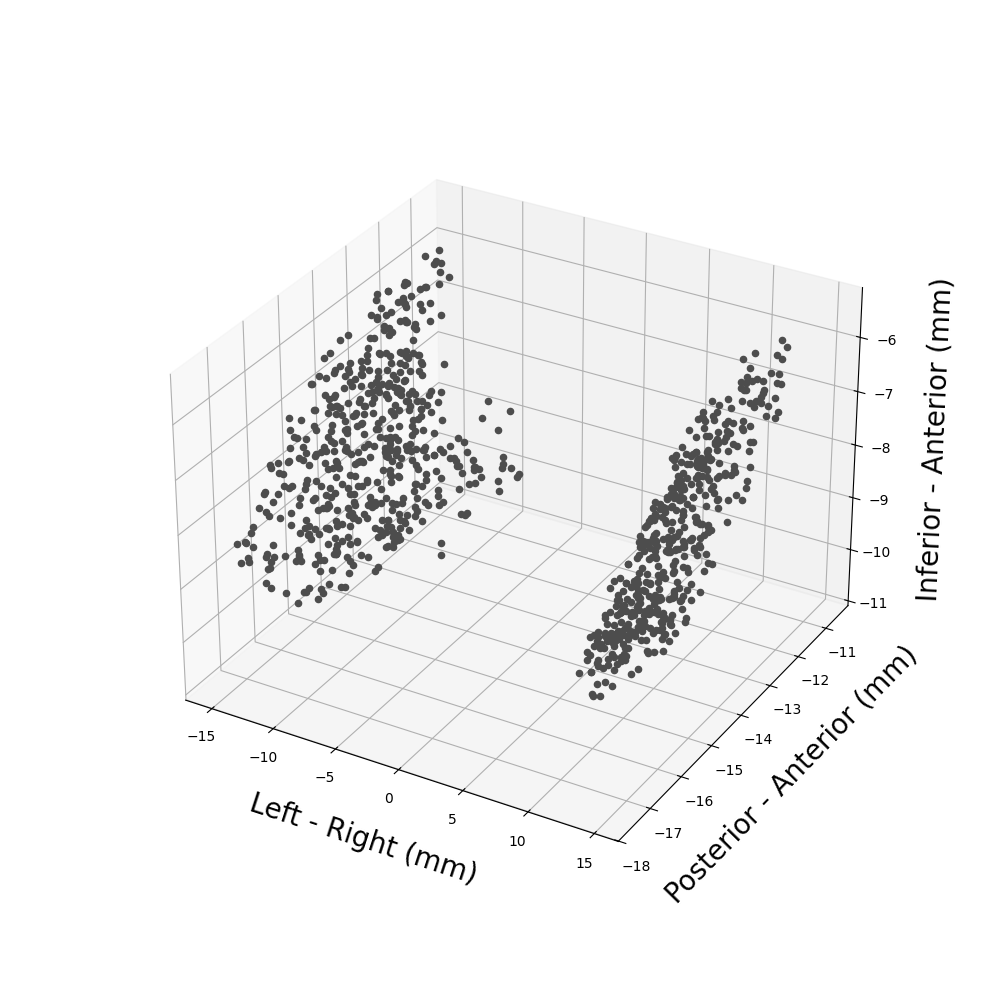

In [7]:
%matplotlib widget

##############################################
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlabel('Left - Right (mm)', fontsize = 20, labelpad = 15)
ax.set_zlabel('Inferior - Anterior (mm)', fontsize = 20, labelpad = 15)
ax.set_ylabel('Posterior - Anterior (mm)', fontsize = 20, labelpad = 15)


##### add in the cortical neurons##############
x_points = world_points[:,0]
y_points = world_points[:,1]
z_points = world_points[:,2]

ax.scatter(x_points, y_points, z_points, c='#4D4D4D', label = "Cortical Neurons",depthshade=False)
plt.show()

# DISTAL

In [8]:
stn_motor_distal = nib.load("./Motor_division_of_STN_atlases/STN_motor_DISTAL_Ewert_2017_left.nii")
data_distal = stn_motor_distal.get_fdata()
indices_distal = np.argwhere(data_distal > 0)
affine_distal = stn_motor_distal.affine

In [9]:
indices_test = np.random.choice(len(indices_distal), size = 1000)
voxel_coords_test = indices_distal[indices_test]
ones = np.ones((1000, 1))
vox_hom = np.hstack([voxel_coords_test, ones])          # (N,4)
world_points = (affine_distal @ vox_hom.T).T[:, :3]

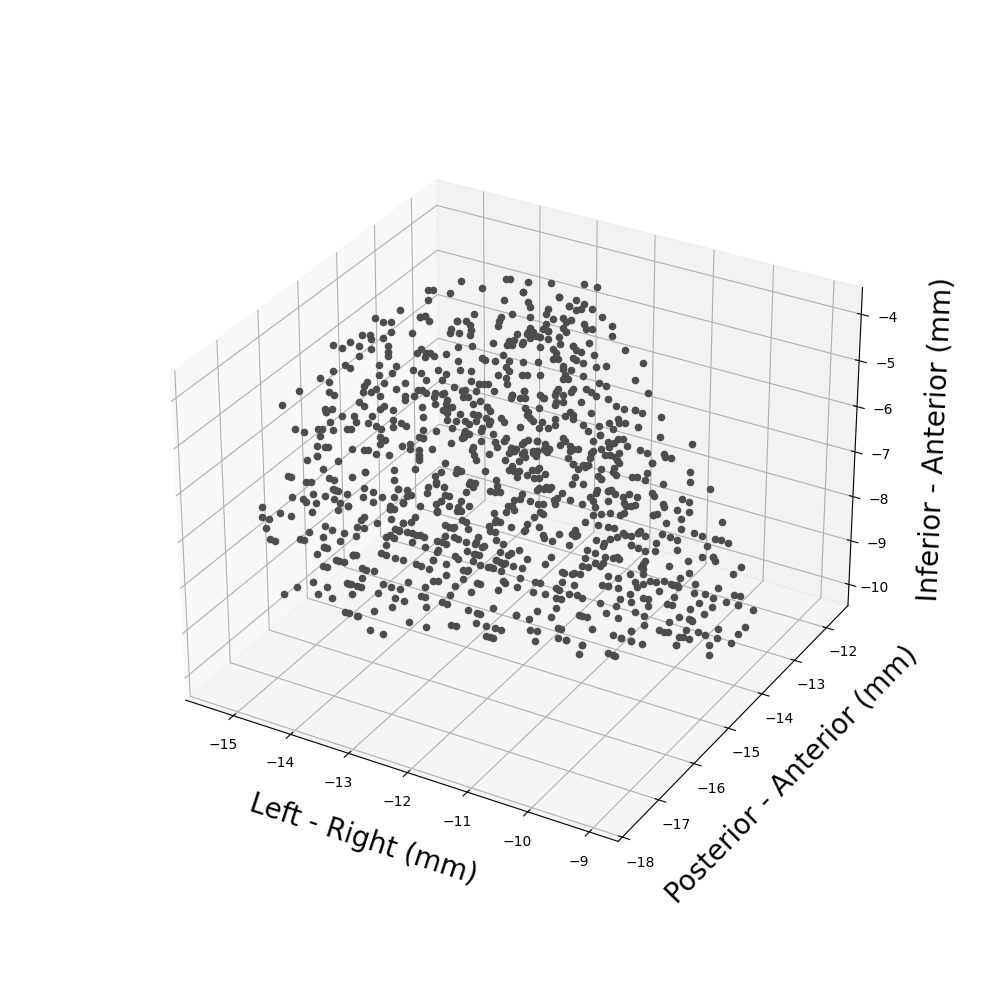

In [10]:
%matplotlib widget

##############################################
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlabel('Left - Right (mm)', fontsize = 20, labelpad = 15)
ax.set_zlabel('Inferior - Anterior (mm)', fontsize = 20, labelpad = 15)
ax.set_ylabel('Posterior - Anterior (mm)', fontsize = 20, labelpad = 15)


##### add in the cortical neurons##############
x_points = world_points[:,0]
y_points = world_points[:,1]
z_points = world_points[:,2]

ax.scatter(x_points, y_points, z_points, c='#4D4D4D', label = "Cortical Neurons",depthshade=False)
plt.show()

# Li 2020

In [11]:
stn_motor_li = nib.load("./Motor_division_of_STN_atlases/STN_motor_Li_2020_left.nii")
data_li = stn_motor_li.get_fdata()
indices_li = np.argwhere(data_li > 0)
affine_li = stn_motor_li.affine

In [12]:
indices_test = np.random.choice(len(indices_li), size = 1000)
voxel_coords_test = indices_li[indices_test]
ones = np.ones((1000, 1))
vox_hom = np.hstack([voxel_coords_test, ones])          # (N,4)
world_points = (affine_li @ vox_hom.T).T[:, :3]

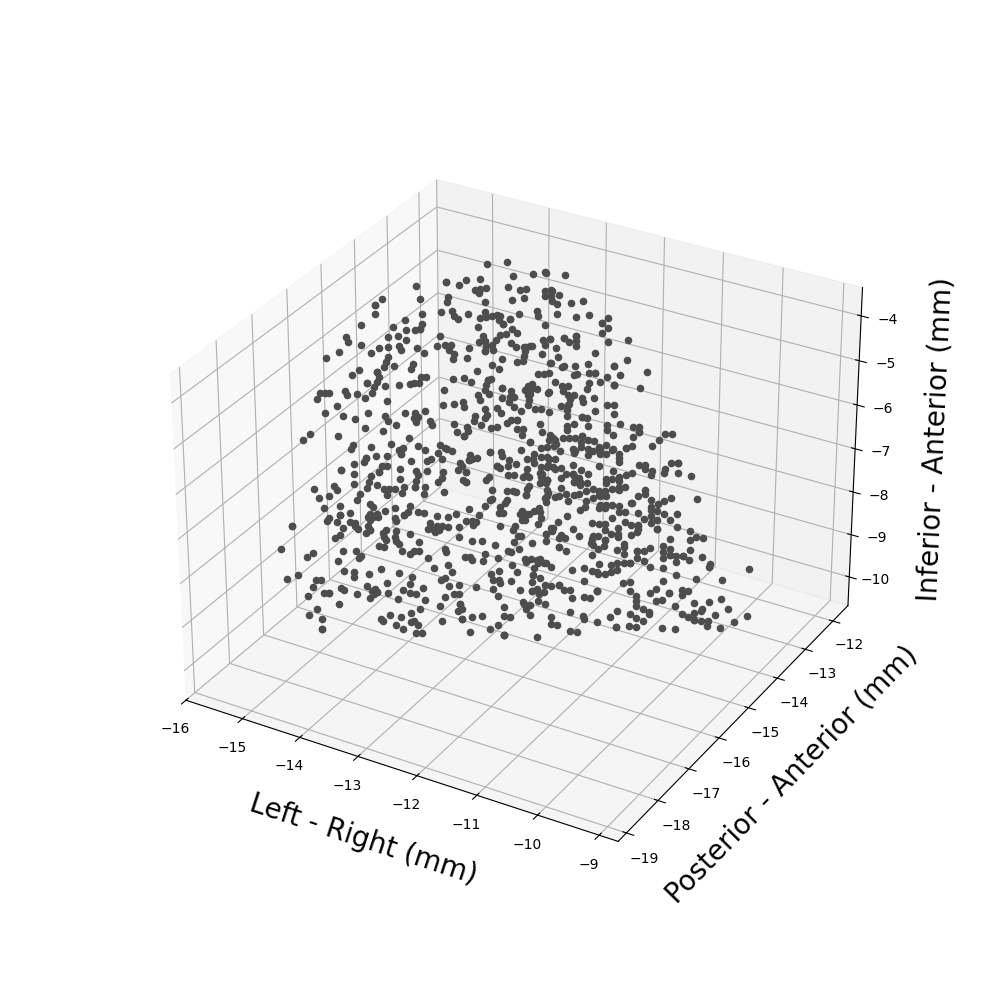

In [13]:
%matplotlib widget

##############################################
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlabel('Left - Right (mm)', fontsize = 20, labelpad = 15)
ax.set_zlabel('Inferior - Anterior (mm)', fontsize = 20, labelpad = 15)
ax.set_ylabel('Posterior - Anterior (mm)', fontsize = 20, labelpad = 15)


##### add in the cortical neurons##############
x_points = world_points[:,0]
y_points = world_points[:,1]
z_points = world_points[:,2]

ax.scatter(x_points, y_points, z_points, c='#4D4D4D', label = "Cortical Neurons",depthshade=False)
plt.show()

# Middlebrooks 2020

In [14]:
stn_motor_middle = nib.load("./Motor_division_of_STN_atlases/STN_motor_Middlebrooks_2020_left.nii")
data_middle = stn_motor_middle.get_fdata()
indices_middle = np.argwhere(data_middle > 0)
affine_middle = stn_motor_middle.affine

In [15]:
indices_test = np.random.choice(len(indices_middle), size = 1000)
voxel_coords_test = indices_middle[indices_test]
ones = np.ones((1000, 1))
vox_hom = np.hstack([voxel_coords_test, ones])          # (N,4)
world_points = (affine_middle @ vox_hom.T).T[:, :3]

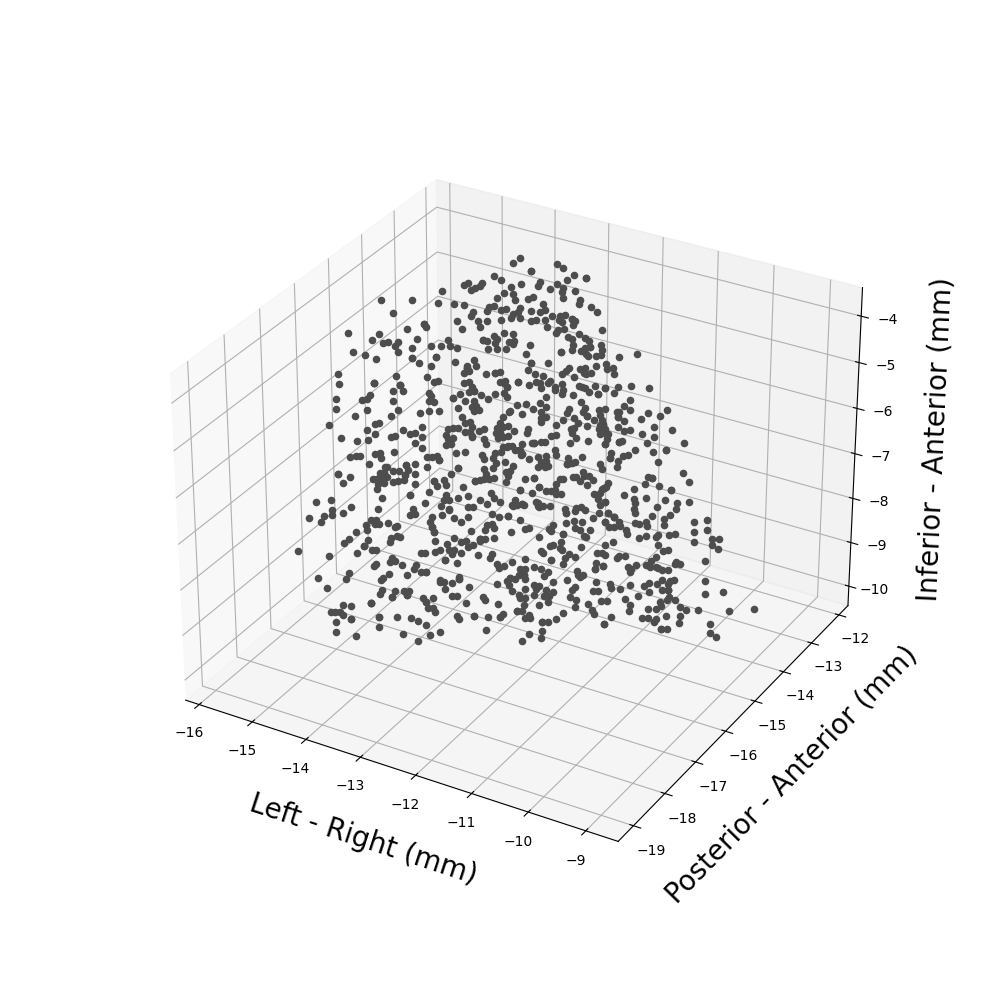

In [16]:
%matplotlib widget

##############################################
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlabel('Left - Right (mm)', fontsize = 20, labelpad = 15)
ax.set_zlabel('Inferior - Anterior (mm)', fontsize = 20, labelpad = 15)
ax.set_ylabel('Posterior - Anterior (mm)', fontsize = 20, labelpad = 15)


##### add in the cortical neurons##############
x_points = world_points[:,0]
y_points = world_points[:,1]
z_points = world_points[:,2]

ax.scatter(x_points, y_points, z_points, c='#4D4D4D', label = "Cortical Neurons",depthshade=False)
plt.show()

# General function

In [3]:
class LeadDBS_atlas_random_point_generator:
    def __init__(self, atlas, stimulating_electrode_position, encapsulation_radius):
        self.atlas = atlas
        self.stimulating_electrode_position = stimulating_electrode_position
        self.encapsulation_radius = encapsulation_radius
        
        
        self.region_data = self.atlas.get_fdata()
        self.affine = self.atlas.affine

        ## Get voxel indices (i,j,k) of valid voxels
        self.region_data_indices = np.argwhere(self.region_data > 0)        


    def generate_positions(self, number_points):
        indices = np.random.choice(len(self.region_data_indices), size = number_points)
        voxel_coords = self.region_data_indices[indices]

        offsets = np.random.normal(0, 0.4, size=(number_points, 3))
        voxel_points = voxel_coords + offsets

        ones = np.ones((number_points, 1))
        vox_hom = np.hstack([voxel_points, ones])          # (N,4)
        world_points = (self.affine @ vox_hom.T).T[:, :3]

        #remove points from the encapsulation layer
        x_coordinates = world_points[:, 0] - self.stimulating_electrode_position[0]
        y_coordinates = world_points[:, 1] - self.stimulating_electrode_position[1]


        mask = (x_coordinates**2 + y_coordinates**2 > self.encapsulation_radius**2) & (x_coordinates < 0)
          

        if mask.sum() < number_points:
            # recursively fill remaining points
            missing = number_points - mask.sum()
            extra = self.generate_positions(missing)
            world_points = np.vstack([world_points[mask], extra])
        else:
            world_points = world_points[mask][:number_points]


        return world_points

In [18]:
atlas = nib.load("./Motor_division_of_STN_atlases/STN_motor_DISTAL_Ewert_2017_left.nii")
electrode_position_mm = np.array([12000,-12000,-8500])/1000
encapsulation_mm = 1135/1000

random_point_generator = LeadDBS_atlas_random_point_generator(atlas, electrode_position_mm, encapsulation_mm)
positions = random_point_generator.generate_positions(1000)

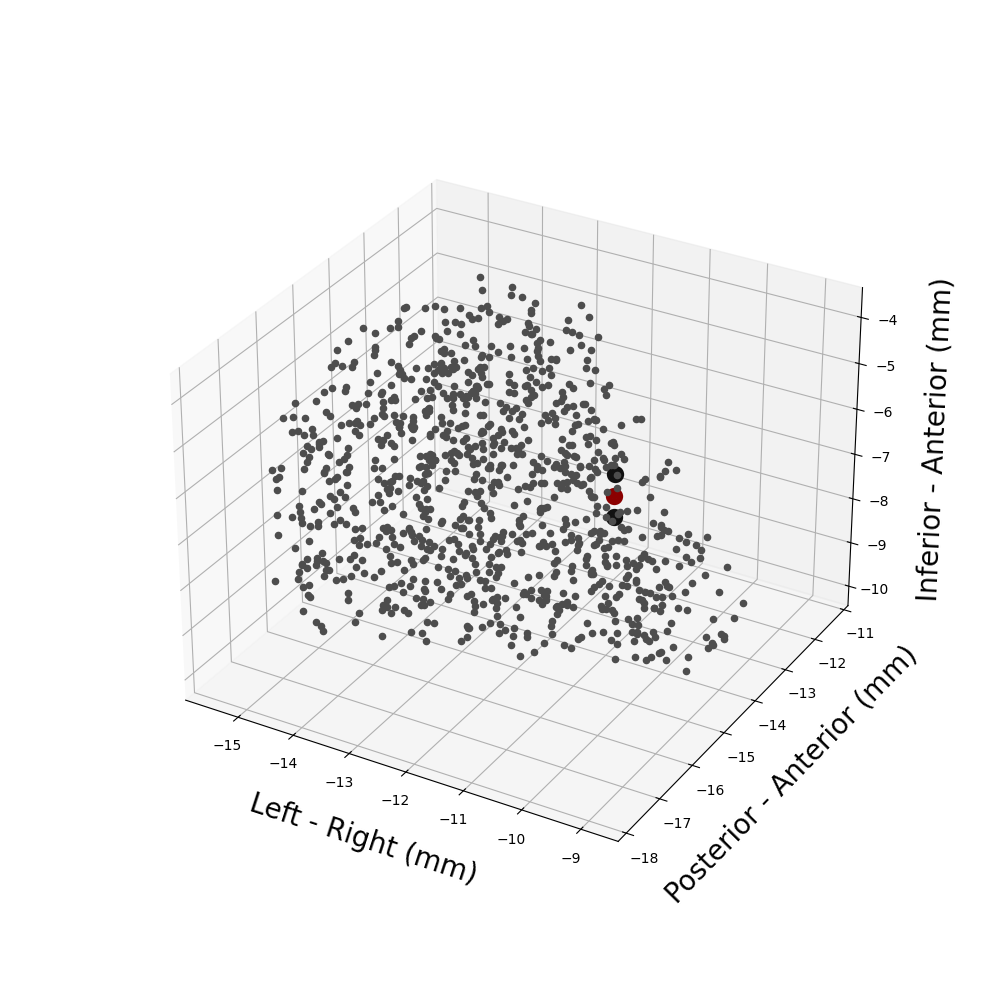

In [19]:
%matplotlib widget


##############################################
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlabel('Left - Right (mm)', fontsize = 20, labelpad = 15)
ax.set_zlabel('Inferior - Anterior (mm)', fontsize = 20, labelpad = 15)
ax.set_ylabel('Posterior - Anterior (mm)', fontsize = 20, labelpad = 15)


##### add in the cortical neurons##############
x_points = positions[:,0]
y_points = positions[:,1]
z_points = positions[:,2]

ax.scatter(x_points, y_points, z_points, c='#4D4D4D', label = "Cortical Neurons",depthshade=False)
ax.scatter(np.array([-12]), np.array([-12]), np.array([-8.5]), c='#8B0000', label = "Stimulating Electrode", linewidth=8)
ax.scatter(np.array([-12,-12]), np.array([-12,-12]), np.array([-8,-9]), color='#111111', depthshade=False, label = "Recording Electrode", linewidth=8)


plt.show()

# Plot all four regions together

In [20]:
atlas_ewert = nib.load("./Motor_division_of_STN_atlases/STN_motor_DISTAL_Ewert_2017_left.nii")
atlas_middle = nib.load("./Motor_division_of_STN_atlases/STN_motor_Middlebrooks_2020_left.nii")
atlas_li = nib.load("./Motor_division_of_STN_atlases/STN_motor_Li_2020_left.nii")
atlas_accolla = nib.load("./Motor_division_of_STN_atlases/STN_motor_Accolla_2014_mixed.nii")


electrode_position_mm = np.array([-12000,-12000,-8500])/1000
encapsulation_mm = 1135/1000

random_point_generator_ewert = LeadDBS_atlas_random_point_generator(atlas_ewert, electrode_position_mm, encapsulation_mm)
positions_ewert = random_point_generator_ewert.generate_positions(1000)

random_point_generator_middle = LeadDBS_atlas_random_point_generator(atlas_middle, electrode_position_mm, encapsulation_mm)
positions_middle = random_point_generator_middle.generate_positions(1000)

random_point_generator_li = LeadDBS_atlas_random_point_generator(atlas_li, electrode_position_mm, encapsulation_mm)
positions_li = random_point_generator_li.generate_positions(1000)

random_point_generator_accolla = LeadDBS_atlas_random_point_generator(atlas_accolla, electrode_position_mm, encapsulation_mm)
positions_accolla = random_point_generator_accolla.generate_positions(1000)

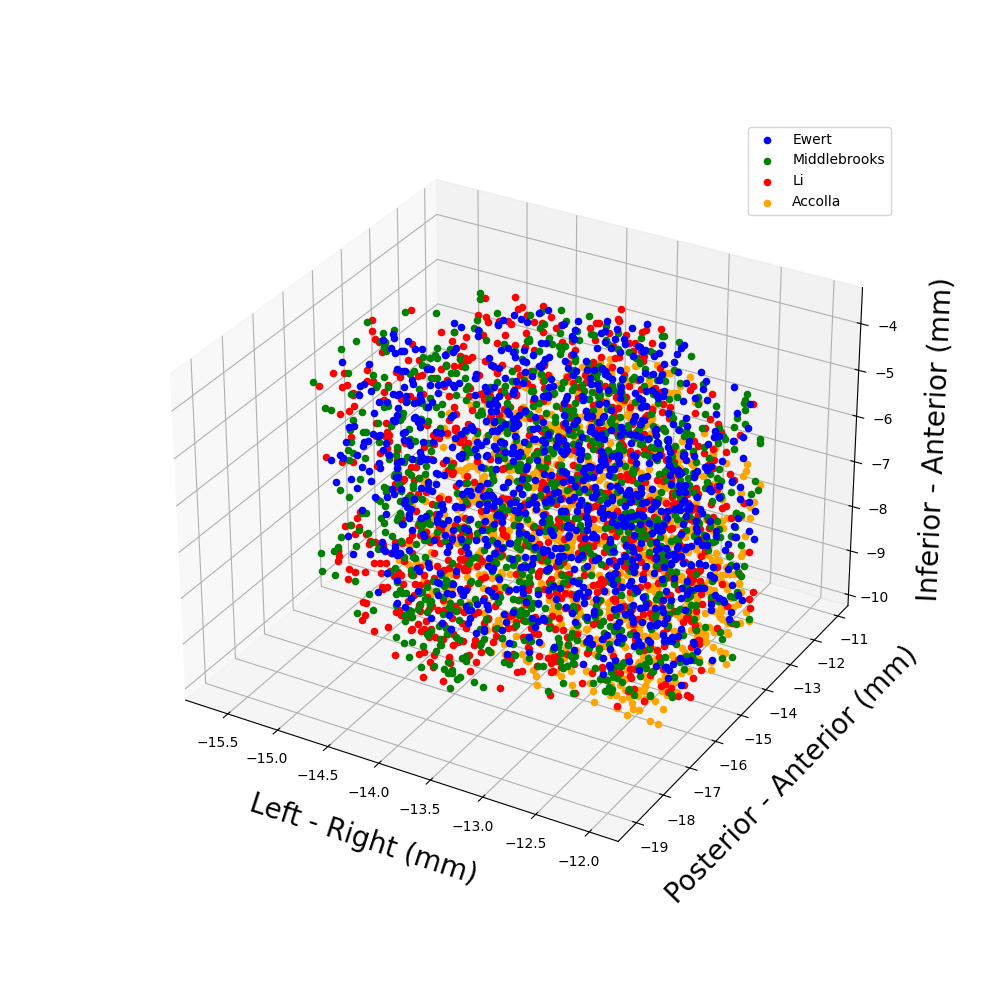

In [21]:
%matplotlib widget


##############################################
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlabel('Left - Right (mm)', fontsize = 20, labelpad = 15)
ax.set_zlabel('Inferior - Anterior (mm)', fontsize = 20, labelpad = 15)
ax.set_ylabel('Posterior - Anterior (mm)', fontsize = 20, labelpad = 15)


##### ewert ##############
x_points_ewert = positions_ewert[:,0]
y_points_ewert = positions_ewert[:,1]
z_points_ewert = positions_ewert[:,2]

ax.scatter(x_points_ewert, y_points_ewert, z_points_ewert, c='blue', label = "Ewert", depthshade=False)

##### middle ##############
x_points_middle = positions_middle[:,0]
y_points_middle = positions_middle[:,1]
z_points_middle = positions_middle[:,2]

ax.scatter(x_points_middle, y_points_middle, z_points_middle, c='green', label = "Middlebrooks", depthshade=False)

##### Li ##############
x_points_li = positions_li[:,0]
y_points_li = positions_li[:,1]
z_points_li = positions_li[:,2]

ax.scatter(x_points_li, y_points_li, z_points_li, c='red', label = "Li", depthshade=False)

##### Accolla ##############
x_points_accolla = positions_accolla[:,0]
y_points_accolla = positions_accolla[:,1]
z_points_accolla = positions_accolla[:,2]

ax.scatter(x_points_accolla, y_points_accolla, z_points_accolla, c='orange', label = "Accolla", depthshade=False)
ax.legend()

#ax.axes.set_xlim3d(left=20, right=0) 

plt.show()

# Add in the Julich

In [2]:
class Julich_brain_cyto_random_point_generator:
    def __init__(self,parcellation, region, space, stimulating_electrode_position, encapsulation_radius):
        #obtain the brain region required
        self.region = siibra.get_region(parcellation, region)

        #get the space required
        self.space = self.region.spaces.get(space)


        self.region_map = self.region.get_regional_map(space, maptype="statistical")
        self.NIfTI_region = self.region_map.fetch()
        self.region_data = self.NIfTI_region.get_fdata()
        self.affine = self.NIfTI_region.affine

        ## Get voxel indices (i,j,k) of valid voxels
        self.region_data_indices = np.argwhere(self.region_data > 0)

        #stimulating electrode position and encapsulation
        self.stimulating_electrode_position = stimulating_electrode_position
        self.encapsulation_radius = encapsulation_radius


    def generate_positions(self, number_points):
        indices = np.random.choice(len(self.region_data_indices), size = number_points)
        voxel_coords = self.region_data_indices[indices]

        offsets = np.random.normal(0, 0.4, size=(number_points, 3))
        voxel_points = voxel_coords + offsets

        ones = np.ones((number_points, 1))
        vox_hom = np.hstack([voxel_points, ones])          # (N,4)
        world_points = (self.affine @ vox_hom.T).T[:, :3]

        #remove points from the encapsulation layer
        x_coordinates = world_points[:, 0] - self.stimulating_electrode_position[0]
        y_coordinates = world_points[:, 1] - self.stimulating_electrode_position[1]


        mask = ~(x_coordinates**2 + y_coordinates**2 < self.encapsulation_radius**2)

        if mask.sum() < number_points:
            # recursively fill remaining points
            missing = number_points - mask.sum()
            extra = self.generate_positions(missing)
            world_points = np.vstack([world_points[mask], extra])
        else:
            world_points = world_points[mask][:number_points]


        return world_points


In [23]:
parcellation = "JULICH_BRAIN_CYTOARCHITECTONIC_ATLAS_V3_1"
region = "STN (Subthalamus) left"
coordinate_space = "MNI_152_ICBM_2009C_NONLINEAR_ASYMMETRIC"
electrode_position_mm = np.array([-12000,-12000,-8500])/1000
encapsulation_mm = 1135/1000

random_point_generator_julich = Julich_brain_cyto_random_point_generator(parcellation,region,coordinate_space, electrode_position_mm, encapsulation_mm)
positions_julich = random_point_generator_julich.generate_positions(1000)


Loading preconfigured Map instances: 100%|█████████████████████████████████████████████| 59/59 [00:01<00:00, 50.69Map/s]
[siibra:WARNING] Map registry contains multiple classes: Map, SparseMap


In [24]:
atlas_ewert = nib.load("./Motor_division_of_STN_atlases/STN_motor_DISTAL_Ewert_2017_left.nii")
atlas_middle = nib.load("./Motor_division_of_STN_atlases/STN_motor_Middlebrooks_2020_left.nii")
atlas_li = nib.load("./Motor_division_of_STN_atlases/STN_motor_Li_2020_left.nii")
atlas_accolla = nib.load("./Motor_division_of_STN_atlases/STN_motor_Accolla_2014_mixed.nii")


electrode_position_mm = np.array([-12000,-12000,-8500])/1000
encapsulation_mm = 1135/1000

random_point_generator_ewert = LeadDBS_atlas_random_point_generator(atlas_ewert, electrode_position_mm, encapsulation_mm)
positions_ewert = random_point_generator_ewert.generate_positions(1000)

random_point_generator_middle = LeadDBS_atlas_random_point_generator(atlas_middle, electrode_position_mm, encapsulation_mm)
positions_middle = random_point_generator_middle.generate_positions(1000)

random_point_generator_li = LeadDBS_atlas_random_point_generator(atlas_li, electrode_position_mm, encapsulation_mm)
positions_li = random_point_generator_li.generate_positions(1000)

random_point_generator_accolla = LeadDBS_atlas_random_point_generator(atlas_accolla, electrode_position_mm, encapsulation_mm)
positions_accolla = random_point_generator_accolla.generate_positions(1000)


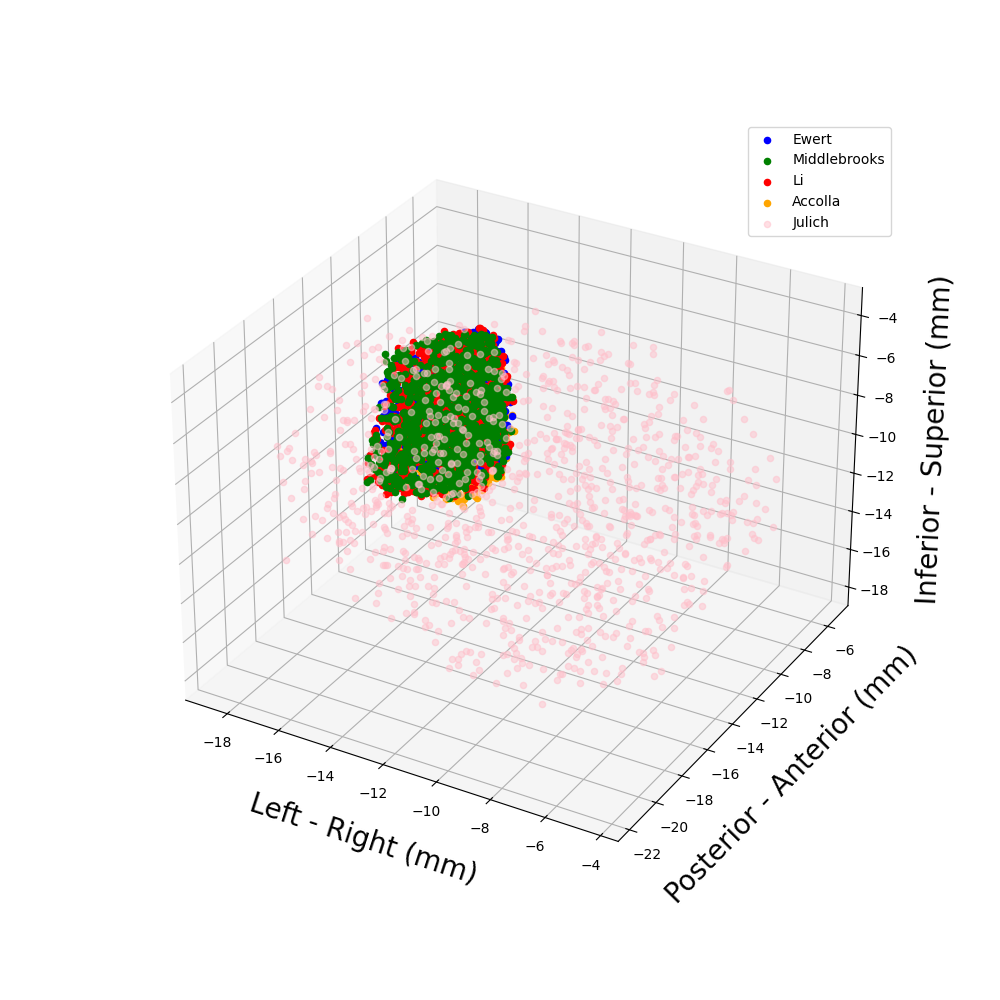

In [25]:
%matplotlib widget


##############################################
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlabel('Left - Right (mm)', fontsize = 20, labelpad = 15)
ax.set_zlabel('Inferior - Superior (mm)', fontsize = 20, labelpad = 15)
ax.set_ylabel('Posterior - Anterior (mm)', fontsize = 20, labelpad = 15)


##### ewert ##############
x_points_ewert = positions_ewert[:,0]
y_points_ewert = positions_ewert[:,1]
z_points_ewert = positions_ewert[:,2]

ax.scatter(x_points_ewert, y_points_ewert, z_points_ewert, c='blue', label = "Ewert", depthshade=False)

##### middle ##############
x_points_middle = positions_middle[:,0]
y_points_middle = positions_middle[:,1]
z_points_middle = positions_middle[:,2]

ax.scatter(x_points_middle, y_points_middle, z_points_middle, c='green', label = "Middlebrooks", depthshade=False)

##### Li ##############
x_points_li = positions_li[:,0]
y_points_li = positions_li[:,1]
z_points_li = positions_li[:,2]

ax.scatter(x_points_li, y_points_li, z_points_li, c='red', label = "Li", depthshade=False)

##### Accolla ##############
x_points_accolla = positions_accolla[:,0]
y_points_accolla = positions_accolla[:,1]
z_points_accolla = positions_accolla[:,2]

ax.scatter(x_points_accolla, y_points_accolla, z_points_accolla, c='orange', label = "Accolla", depthshade=False)

##### Julich ##############
x_points_julich = positions_julich[:,0]
y_points_julich = positions_julich[:,1]
z_points_julich = positions_julich[:,2]

ax.scatter(x_points_julich, y_points_julich, z_points_julich, c='pink', label = "Julich", depthshade=False, alpha = 0.5)

#ax.axes.set_xlim3d(left=-20, right=0) 
ax.legend()

plt.show()

# Hyperdirect Pathway

In [26]:
stn_motor_HDP = nib.load("./HDP_Pos_Neg.nii")
data_HDP = stn_motor_HDP.get_fdata()
indices_HDP = np.argwhere(data_HDP > 0)
affine_HDP = stn_motor_HDP.affine

In [4]:
%matplotlib widget

nonzero_indices = np.argwhere(data_HDP > 0)
nonzero_values = data_HDP[data_HDP > 0]

ones = np.ones((len(nonzero_indices), 1))
vox_hom = np.hstack([nonzero_indices, ones])          # (N,4)
nonzero_indices = (affine_STN_targets @ vox_hom.T).T[:, :3]

# Step 2: Plot as 3D scatter
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Split coordinates
x, y, z = nonzero_indices[:, 0], nonzero_indices[:, 1], nonzero_indices[:, 2]

# Normalize values for color mapping
#norm_values = (nonzero_values - nonzero_values.min()) / (nonzero_values.ptp())

# Scatter plot
sc = ax.scatter(x, y, z, c=nonzero_values, cmap='viridis', s=2)

# Color bar
plt.colorbar(sc, ax=ax, label='Normalized Value')

# Labels
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Scatter of Non-Zero Voxels')

plt.show()

NameError: name 'data_HDP' is not defined

In [ ]:
indices_test = np.random.choice(len(indices_HDP), size = 10000)
voxel_coords_test = indices_HDP[indices_test]
ones = np.ones((10000, 1))
vox_hom = np.hstack([voxel_coords_test, ones])          # (N,4)
world_points = (affine_HDP @ vox_hom.T).T[:, :3]

In [ ]:
%matplotlib widget

##############################################
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlabel('Left - Right (mm)', fontsize = 20, labelpad = 15)
ax.set_zlabel('Inferior - Anterior (mm)', fontsize = 20, labelpad = 15)
ax.set_ylabel('Posterior - Anterior (mm)', fontsize = 20, labelpad = 15)


##### add in the cortical neurons##############
x_points = world_points[:,0]
y_points = world_points[:,1]
z_points = world_points[:,2]

ax.scatter(x_points, y_points, z_points, c='#4D4D4D', label = "HDP",depthshade=False)
plt.show()

# Add in the hyperdirect pathway

In [4]:
parcellation = "JULICH_BRAIN_CYTOARCHITECTONIC_ATLAS_V3_1"
region = "STN (Subthalamus) left"
coordinate_space = "MNI_152_ICBM_2009C_NONLINEAR_ASYMMETRIC"
electrode_position_mm = np.array([-12000,-12000,-8500])/1000
encapsulation_mm = 1135/1000

random_point_generator_julich = Julich_brain_cyto_random_point_generator(parcellation,region,coordinate_space, electrode_position_mm, encapsulation_mm)
positions_julich = random_point_generator_julich.generate_positions(1000)

Loading preconfigured Map instances: 100%|████████████████████████████████████████████| 59/59 [00:00<00:00, 128.94Map/s]
[siibra:WARNING] Map registry contains multiple classes: SparseMap, Map


In [13]:

atlas_ewert = nib.load("Publication_Figures/Motor_division_of_STN_atlases/STN_motor_DISTAL_Ewert_2017_left.nii")
atlas_middle = nib.load("Publication_Figures/Motor_division_of_STN_atlases/STN_motor_Middlebrooks_2020_left.nii")
atlas_li = nib.load("Publication_Figures/Motor_division_of_STN_atlases/STN_motor_Li_2020_left.nii")
atlas_accolla = nib.load("Publication_Figures/Motor_division_of_STN_atlases/STN_motor_Accolla_2014_mixed.nii")
atlas_HDP = nib.load("Publication_Figures/HDP_Pos_Neg.nii")
atlas_IC = nib.load("Publication_Figures/IC_left.nii")


electrode_position_mm = np.array([-12000,-12000,-8500])/1000
encapsulation_mm = 1135/1000

random_point_generator_ewert = LeadDBS_atlas_random_point_generator(atlas_ewert, electrode_position_mm, encapsulation_mm)
positions_ewert = random_point_generator_ewert.generate_positions(1000)

random_point_generator_middle = LeadDBS_atlas_random_point_generator(atlas_middle, electrode_position_mm, encapsulation_mm)
positions_middle = random_point_generator_middle.generate_positions(1000)

random_point_generator_li = LeadDBS_atlas_random_point_generator(atlas_li, electrode_position_mm, encapsulation_mm)
positions_li = random_point_generator_li.generate_positions(1000)

random_point_generator_accolla = LeadDBS_atlas_random_point_generator(atlas_accolla, electrode_position_mm, encapsulation_mm)
positions_accolla = random_point_generator_accolla.generate_positions(1000)

random_point_generator_HDP = LeadDBS_atlas_random_point_generator(atlas_HDP, electrode_position_mm, encapsulation_mm)
positions_HDP = random_point_generator_HDP.generate_positions(1000)
'''
random_point_generator_IC = LeadDBS_atlas_random_point_generator(atlas_IC, electrode_position_mm, encapsulation_mm)
positions_IC = random_point_generator_IC.generate_positions(1000)
'''

'\nrandom_point_generator_IC = LeadDBS_atlas_random_point_generator(atlas_IC, electrode_position_mm, encapsulation_mm)\npositions_IC = random_point_generator_IC.generate_positions(1000)\n'

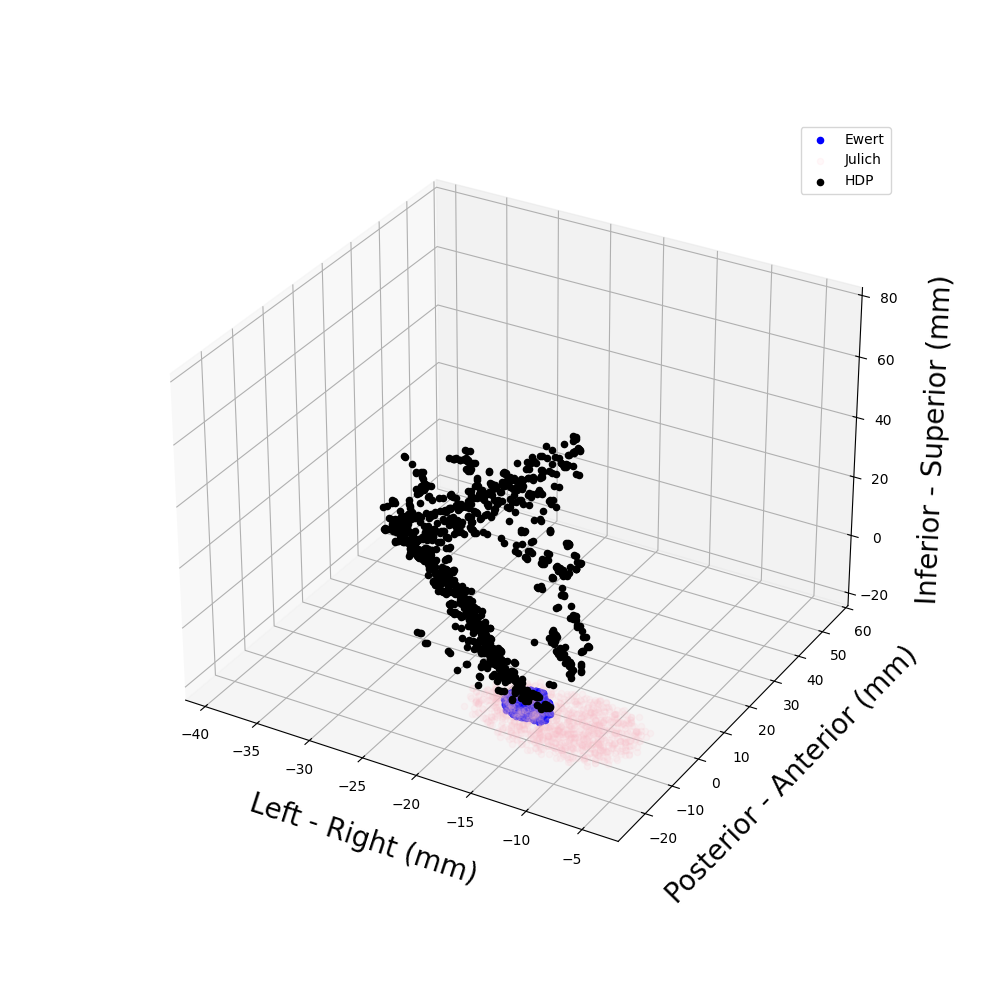

In [14]:
%matplotlib widget


##############################################
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlabel('Left - Right (mm)', fontsize = 20, labelpad = 15)
ax.set_zlabel('Inferior - Superior (mm)', fontsize = 20, labelpad = 15)
ax.set_ylabel('Posterior - Anterior (mm)', fontsize = 20, labelpad = 15)


##### ewert ##############
x_points_ewert = positions_ewert[:,0]
y_points_ewert = positions_ewert[:,1]
z_points_ewert = positions_ewert[:,2]

ax.scatter(x_points_ewert, y_points_ewert, z_points_ewert, c='blue', label = "Ewert", depthshade=False)
'''
##### middle ##############
x_points_middle = positions_middle[:,0]
y_points_middle = positions_middle[:,1]
z_points_middle = positions_middle[:,2]

ax.scatter(x_points_middle, y_points_middle, z_points_middle, c='green', label = "Middlebrooks", depthshade=False)

##### Li ##############
x_points_li = positions_li[:,0]
y_points_li = positions_li[:,1]
z_points_li = positions_li[:,2]

ax.scatter(x_points_li, y_points_li, z_points_li, c='red', label = "Li", depthshade=False)

##### Accolla ##############
x_points_accolla = positions_accolla[:,0]
y_points_accolla = positions_accolla[:,1]
z_points_accolla = positions_accolla[:,2]

ax.scatter(x_points_accolla, y_points_accolla, z_points_accolla, c='orange', label = "Accolla", depthshade=False)
'''
##### Julich ##############
x_points_julich = positions_julich[:,0]
y_points_julich = positions_julich[:,1]
z_points_julich = positions_julich[:,2]

ax.scatter(x_points_julich, y_points_julich, z_points_julich, c='pink', label = "Julich", depthshade=False, alpha = 0.1)

##### HDP ##############
x_points_HDP = positions_HDP[:,0]
y_points_HDP = positions_HDP[:,1]
z_points_HDP = positions_HDP[:,2]

ax.scatter(x_points_HDP, y_points_HDP, z_points_HDP, c='black', label = "HDP", depthshade=False, alpha = 1)

#ax.axes.set_xlim3d(left=-40, right=0) 
ax.legend()

plt.show()

# Add in the positions of the STN targets

In [ ]:
STN_targets = nib.load("./Horn_2017_PD_STN_targets.nii")
data_STN_targets = STN_targets.get_fdata()
indices_STN_targets = np.argwhere(data_STN_targets > 0)
affine_STN_targets = STN_targets.affine

In [ ]:
indices_test = np.random.choice(len(indices_STN_targets), size = 10000)
voxel_coords_test = indices_STN_targets[indices_test]
ones = np.ones((10000, 1))
vox_hom = np.hstack([voxel_coords_test, ones])          # (N,4)
world_points = (affine_STN_targets @ vox_hom.T).T[:, :3]

In [ ]:
%matplotlib widget

nonzero_indices = np.argwhere(data_STN_targets > 0.8)
nonzero_values = data_STN_targets[data_STN_targets > 0.8]

ones = np.ones((len(nonzero_indices), 1))
vox_hom = np.hstack([nonzero_indices, ones])          # (N,4)
nonzero_indices = (affine_STN_targets @ vox_hom.T).T[:, :3]

# Step 2: Plot as 3D scatter
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Split coordinates
x, y, z = nonzero_indices[:, 0], nonzero_indices[:, 1], nonzero_indices[:, 2]

# Normalize values for color mapping
#norm_values = (nonzero_values - nonzero_values.min()) / (nonzero_values.ptp())

# Scatter plot
sc = ax.scatter(x, y, z, c=nonzero_values, cmap='viridis', s=2)

# Color bar
plt.colorbar(sc, ax=ax, label='Normalized Value')

# Labels
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Scatter of Non-Zero Voxels')

plt.show()

# Adding in the IC

In [8]:
atlas_IC = nib.load("Publication_Figures/IC_left.nii")
data_IC = atlas_IC.get_fdata()
indices_IC = np.argwhere(data_IC > 0)
affine_IC = atlas_IC.affine

In [10]:
indices_test = np.random.choice(len(indices_IC), size = 10000)
voxel_coords_test = indices_IC[indices_test]
ones = np.ones((10000, 1))
vox_hom = np.hstack([voxel_coords_test, ones])          # (N,4)
world_points = (affine_IC @ vox_hom.T).T[:, :3]

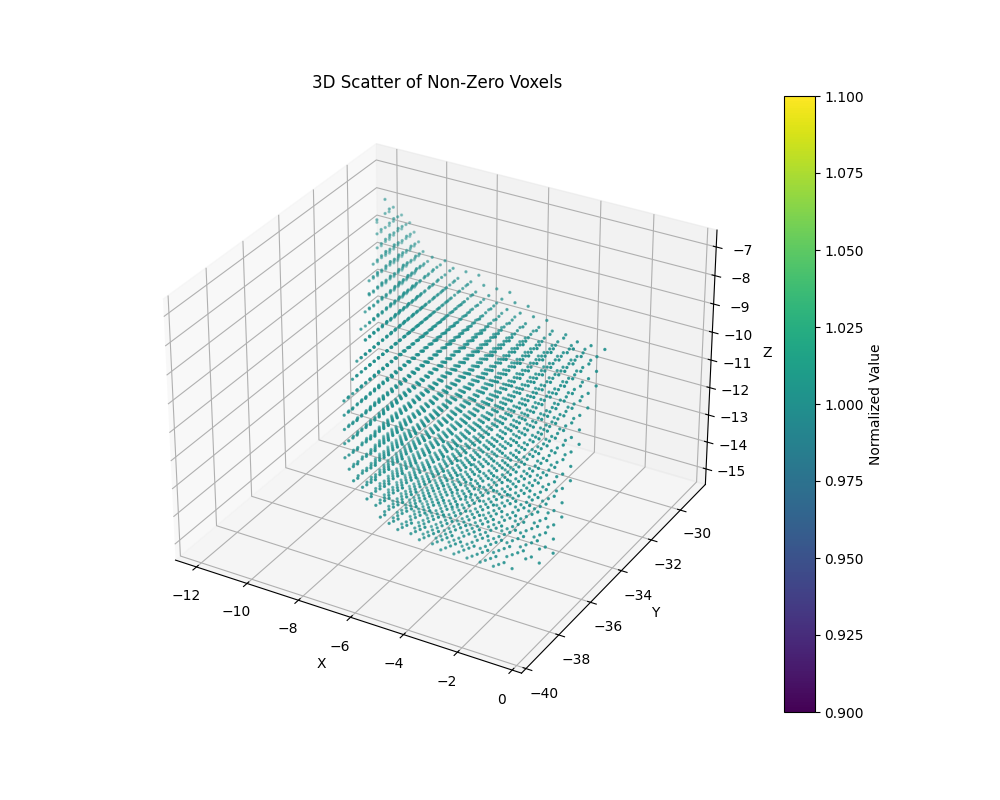

In [12]:
%matplotlib widget

nonzero_indices = np.argwhere(data_IC > 0.8)
nonzero_values = data_IC[data_IC > 0.8]

ones = np.ones((len(nonzero_indices), 1))
vox_hom = np.hstack([nonzero_indices, ones])          # (N,4)
nonzero_indices = (affine_IC  @ vox_hom.T).T[:, :3]

# Step 2: Plot as 3D scatter
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Split coordinates
x, y, z = nonzero_indices[:, 0], nonzero_indices[:, 1], nonzero_indices[:, 2]

# Normalize values for color mapping
#norm_values = (nonzero_values - nonzero_values.min()) / (nonzero_values.ptp())

# Scatter plot
sc = ax.scatter(x, y, z, c=nonzero_values, cmap='viridis', s=2)

# Color bar
plt.colorbar(sc, ax=ax, label='Normalized Value')

# Labels
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Scatter of Non-Zero Voxels')

plt.show()